In [1]:
# ============================================================
# EEG-BCI Stroke Rehab Full Updated Pipeline
# CSP+LDA + Regularized CSP + Time Window Search + FBCSP
# ============================================================

import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

import mne
from mne.decoding import CSP

from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score




In [2]:
# =========================
# 1. SETTINGS
# =========================

DATA_DIR = "E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set"  

CH_NAMES = [
    "FC3", "FCz", "FC4",
    "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
    "CP3", "CP1", "CPz", "CP2", "CP4",
    "Pz"
]

EVENT_ID = {
    "left_hand": 1,
    "right_hand": 2
}

PATIENTS = ["P1", "P2", "P3"]
SESSIONS = ["pre", "post"]




<>:5: SyntaxWarning: invalid escape sequence '\I'
<>:5: SyntaxWarning: invalid escape sequence '\I'
C:\Users\dmcol\AppData\Local\Temp\ipykernel_9040\2470167431.py:5: SyntaxWarning: invalid escape sequence '\I'
  DATA_DIR = "E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set"


In [3]:
# =========================
# 2. BASIC LOADING
# =========================

def load_mat_file(filepath, scale_to_volts=True):
    mat = sio.loadmat(filepath)

    fs = int(mat["fs"].squeeze())
    y = mat["y"]                  # samples x channels
    trig = mat["trig"].squeeze()  # samples

    if scale_to_volts:
        y = y * 1e-6

    return y, trig, fs


def extract_events_from_trigger(trig):
    trig = trig.flatten()

    # Detect transition from 0 to +1 or 0 to -1
    onsets = np.where(np.diff((trig != 0).astype(int)) == 1)[0] + 1
    labels_original = trig[onsets]

    # Convert: +1 -> 1 left, -1 -> 2 right
    event_codes = np.where(labels_original == 1, 1, 2)

    events = np.column_stack([
        onsets,
        np.zeros(len(onsets), dtype=int),
        event_codes
    ])

    return events, event_codes


def make_raw_from_mat(filepath, l_freq=8.0, h_freq=30.0):
    y, trig, fs = load_mat_file(filepath)

    info = mne.create_info(
        ch_names=CH_NAMES,
        sfreq=fs,
        ch_types=["eeg"] * len(CH_NAMES)
    )

    montage = mne.channels.make_standard_montage("standard_1020")
    info.set_montage(montage, on_missing="ignore")

    raw = mne.io.RawArray(y.T, info, verbose=False)
    raw.set_eeg_reference('average', projection=False)
    raw.filter(
        l_freq=l_freq,
        h_freq=h_freq,
        fir_design="firwin",
        verbose=False
    )

    events, labels = extract_events_from_trigger(trig)

    return raw, events, labels


def make_epochs_from_mat(
    filepath,
    tmin=2.0,
    tmax=8.0,
    l_freq=8.0,
    h_freq=30.0,
    baseline=True
):
    raw, events, labels = make_raw_from_mat(
        filepath,
        l_freq=l_freq,
        h_freq=h_freq
    )

    if baseline:
        baseline_range = (tmin, tmin + 0.5)
    else:
        baseline_range = None

    epochs = mne.Epochs(
        raw,
        events,
        event_id=EVENT_ID,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline_range,
        preload=True,
        picks="eeg",
        verbose=False
    )

    y = epochs.events[:, 2]

    return epochs, y




In [4]:
# =========================
# 3. TRAIN-ONLY Z-SCORE
# =========================

def fit_zscore_on_train(X_train):
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True)

    std[std == 0] = 1.0

    return mean, std


def apply_zscore(X, mean, std):
    return (X - mean) / std




In [5]:
# =========================
# 4. VISUALIZATION
# =========================

def plot_trial_16_channels(epochs, labels, trial_idx=0):
    X = epochs.get_data()
    trial = X[trial_idx]
    times = epochs.times

    label_name = "LEFT hand" if labels[trial_idx] == 1 else "RIGHT hand"

    plt.figure(figsize=(14, 9))

    offset = np.max(np.abs(trial)) * 1.5
    if offset == 0:
        offset = 1

    for ch in range(trial.shape[0]):
        plt.plot(times, trial[ch] + ch * offset, linewidth=0.8)
        plt.text(times[0], ch * offset, CH_NAMES[ch], fontsize=8, va="center")

    plt.title(f"16-channel EEG waveform | Trial {trial_idx} | True label: {label_name}")
    plt.xlabel("Time relative to trigger onset (s)")
    plt.ylabel("Channels with vertical offset")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_trial_channel_image(epochs, labels, trial_idx=0):
    X = epochs.get_data()
    trial = X[trial_idx]
    times = epochs.times

    label_name = "LEFT hand" if labels[trial_idx] == 1 else "RIGHT hand"

    plt.figure(figsize=(12, 6))

    im = plt.imshow(
        trial,
        aspect="auto",
        origin="lower",
        extent=[times[0], times[-1], 0, len(CH_NAMES)-1]
    )

    plt.colorbar(im, label="EEG amplitude (V)")
    plt.yticks(np.arange(len(CH_NAMES)), CH_NAMES)
    plt.xlabel("Time relative to trigger onset (s)")
    plt.ylabel("EEG channel")
    plt.title(f"EEG channel intensity image | Trial {trial_idx} | {label_name}")
    plt.tight_layout()
    plt.show()


def plot_topomap_at_time(epochs, labels, trial_idx=0, time_sec=3.0):
    X = epochs.get_data()
    times = epochs.times

    time_idx = np.argmin(np.abs(times - time_sec))
    values = X[trial_idx, :, time_idx]

    label_name = "LEFT hand" if labels[trial_idx] == 1 else "RIGHT hand"

    fig, ax = plt.subplots(figsize=(6, 5))

    mne.viz.plot_topomap(
        values,
        epochs.info,
        axes=ax,
        show=False,
        contours=6
    )

    ax.set_title(
        f"Topomap | Trial {trial_idx} | t={times[time_idx]:.2f}s | {label_name}"
    )

    plt.show()




In [6]:
# =========================
# 5. IMPROVED CSP + LDA
# =========================

def build_csp_lda_pipeline(
    n_components=4,
    regularized=True
):
    if regularized:
        csp_reg = "ledoit_wolf"
        lda = LDA(solver="lsqr", shrinkage="auto")
    else:
        csp_reg = None
        lda = LDA()

    clf = Pipeline([
        ("csp", CSP(
            n_components=n_components,
            reg=csp_reg,
            log=True,
            norm_trace=False
        )),
        ("lda", lda)
    ])

    return clf


def run_csp_lda_with_all_accuracies(
    train_file,
    test_file,
    tmin=2.0,
    tmax=8.0,
    l_freq=8.0,
    h_freq=30.0,
    use_zscore=True,
    regularized=True,
    cv_folds=5,
    plot_confusion=True
):
    ep_train, y_train = make_epochs_from_mat(
        train_file,
        tmin=tmin,
        tmax=tmax,
        l_freq=l_freq,
        h_freq=h_freq,
        baseline=True
    )

    ep_test, y_test = make_epochs_from_mat(
        test_file,
        tmin=tmin,
        tmax=tmax,
        l_freq=l_freq,
        h_freq=h_freq,
        baseline=True
    )

    X_train = ep_train.get_data()
    X_test = ep_test.get_data()

    if use_zscore:
        mean, std = fit_zscore_on_train(X_train)
        X_train = apply_zscore(X_train, mean, std)
        X_test = apply_zscore(X_test, mean, std)

    clf = build_csp_lda_pipeline(
        n_components=4,
        regularized=regularized
    )

    cv = StratifiedKFold(
        n_splits=cv_folds,
        shuffle=True,
        random_state=42
    )

    cv_scores = cross_val_score(
        clf,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    clf.fit(X_train, y_train)

    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred) * 100
    cv_mean = cv_scores.mean() * 100
    cv_std = cv_scores.std() * 100
    test_acc = accuracy_score(y_test, y_test_pred) * 100

    print("====================================")
    print(f"Train file : {os.path.basename(train_file)}")
    print(f"Test file  : {os.path.basename(test_file)}")
    print(f"Window     : {tmin:.1f}s to {tmax:.1f}s")
    print(f"Band       : {l_freq:.1f}-{h_freq:.1f} Hz")
    print("------------------------------------")
    print(f"Training Accuracy    : {train_acc:.2f}%")
    print(f"CV Accuracy          : {cv_mean:.2f}% ± {cv_std:.2f}%")
    print(f"Unseen Test Accuracy : {test_acc:.2f}%")
    print("====================================")

    if plot_confusion:
        cm = confusion_matrix(y_test, y_test_pred, labels=[1, 2])

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Left", "Right"]
        )

        disp.plot()
        plt.title(f"CSP+LDA Test Confusion Matrix\nAccuracy = {test_acc:.2f}%")
        plt.show()

    return {
        "train_accuracy": train_acc,
        "cv_accuracy_mean": cv_mean,
        "cv_accuracy_std": cv_std,
        "test_accuracy": test_acc,
        "model": clf,
        "tmin": tmin,
        "tmax": tmax,
        "band": (l_freq, h_freq)
    }




In [7]:
# =========================
# 6. TIME WINDOW SEARCH
# =========================

def search_best_time_window(
    train_file,
    test_file,
    windows=None,
    l_freq=8.0,
    h_freq=30.0,
    use_zscore=True,
    regularized=True
):
    if windows is None:
        windows = [
            (2.0, 4.0),
            (2.0, 5.0),
            (2.0, 6.0),
            (2.0, 8.0),
            (2.5, 5.5),
            (3.0, 6.0),
            (3.0, 8.0),
            (4.0, 8.0)
        ]

    results = []

    for tmin, tmax in windows:
        result = run_csp_lda_with_all_accuracies(
            train_file=train_file,
            test_file=test_file,
            tmin=tmin,
            tmax=tmax,
            l_freq=l_freq,
            h_freq=h_freq,
            use_zscore=use_zscore,
            regularized=regularized,
            cv_folds=5,
            plot_confusion=False
        )

        results.append(result)

    best = max(results, key=lambda r: r["test_accuracy"])

    print("\n========== BEST TIME WINDOW ==========")
    print(f"Best window : {best['tmin']}s to {best['tmax']}s")
    print(f"Test acc    : {best['test_accuracy']:.2f}%")
    print("======================================")

    return best, results




In [8]:
# =========================
# 7. FILTER BANK CSP
# =========================

FBCSP_BANDS = [
    (8, 12),
    (12, 16),
    (16, 20),
    (20, 24),
    (24, 30)
]


def extract_fbcsp_features(
    train_file,
    test_file,
    tmin=2.0,
    tmax=8.0,
    bands=FBCSP_BANDS,
    n_components_per_band=2,
    use_zscore=True
):
    train_features = []
    test_features = []

    y_train_final = None
    y_test_final = None

    for l_freq, h_freq in bands:
        ep_train, y_train = make_epochs_from_mat(
            train_file,
            tmin=tmin,
            tmax=tmax,
            l_freq=l_freq,
            h_freq=h_freq,
            baseline=True
        )

        ep_test, y_test = make_epochs_from_mat(
            test_file,
            tmin=tmin,
            tmax=tmax,
            l_freq=l_freq,
            h_freq=h_freq,
            baseline=True
        )

        X_train = ep_train.get_data()
        X_test = ep_test.get_data()

        if use_zscore:
            mean, std = fit_zscore_on_train(X_train)
            X_train = apply_zscore(X_train, mean, std)
            X_test = apply_zscore(X_test, mean, std)

        csp = CSP(
            n_components=n_components_per_band,
            reg="ledoit_wolf",
            log=True,
            norm_trace=False
        )

        X_train_band = csp.fit_transform(X_train, y_train)
        X_test_band = csp.transform(X_test)

        train_features.append(X_train_band)
        test_features.append(X_test_band)

        y_train_final = y_train
        y_test_final = y_test

    X_train_fbcsp = np.concatenate(train_features, axis=1)
    X_test_fbcsp = np.concatenate(test_features, axis=1)

    return X_train_fbcsp, y_train_final, X_test_fbcsp, y_test_final


def run_fbcsp_lda(
    train_file,
    test_file,
    tmin=2.0,
    tmax=8.0,
    bands=FBCSP_BANDS,
    use_zscore=True,
    cv_folds=5,
    plot_confusion=True
):
    X_train, y_train, X_test, y_test = extract_fbcsp_features(
        train_file=train_file,
        test_file=test_file,
        tmin=tmin,
        tmax=tmax,
        bands=bands,
        n_components_per_band=2,
        use_zscore=use_zscore
    )

    clf = LDA(solver="lsqr", shrinkage="auto")

    cv = StratifiedKFold(
        n_splits=cv_folds,
        shuffle=True,
        random_state=42
    )

    cv_scores = cross_val_score(
        clf,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    clf.fit(X_train, y_train)

    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred) * 100
    cv_mean = cv_scores.mean() * 100
    cv_std = cv_scores.std() * 100
    test_acc = accuracy_score(y_test, y_test_pred) * 100

    print("====================================")
    print(f"FBCSP + LDA")
    print(f"Train file : {os.path.basename(train_file)}")
    print(f"Test file  : {os.path.basename(test_file)}")
    print(f"Window     : {tmin:.1f}s to {tmax:.1f}s")
    print(f"Bands      : {bands}")
    print("------------------------------------")
    print(f"Training Accuracy    : {train_acc:.2f}%")
    print(f"CV Accuracy          : {cv_mean:.2f}% ± {cv_std:.2f}%")
    print(f"Unseen Test Accuracy : {test_acc:.2f}%")
    print("====================================")

    if plot_confusion:
        cm = confusion_matrix(y_test, y_test_pred, labels=[1, 2])

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Left", "Right"]
        )

        disp.plot()
        plt.title(f"FBCSP + LDA Test Confusion Matrix\nAccuracy = {test_acc:.2f}%")
        plt.show()

    return {
        "train_accuracy": train_acc,
        "cv_accuracy_mean": cv_mean,
        "cv_accuracy_std": cv_std,
        "test_accuracy": test_acc,
        "model": clf,
        "tmin": tmin,
        "tmax": tmax,
        "bands": bands
    }




EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


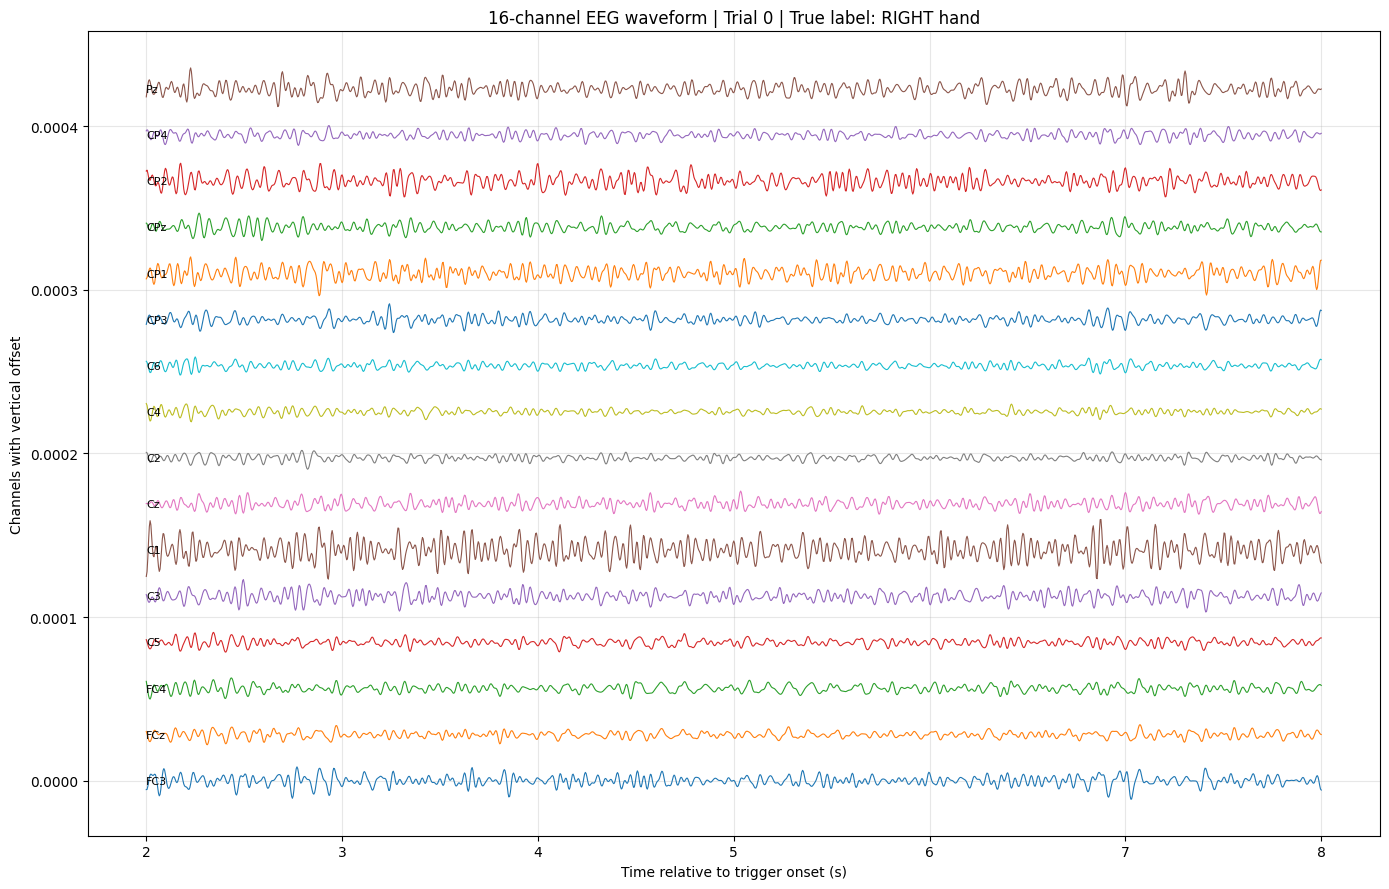

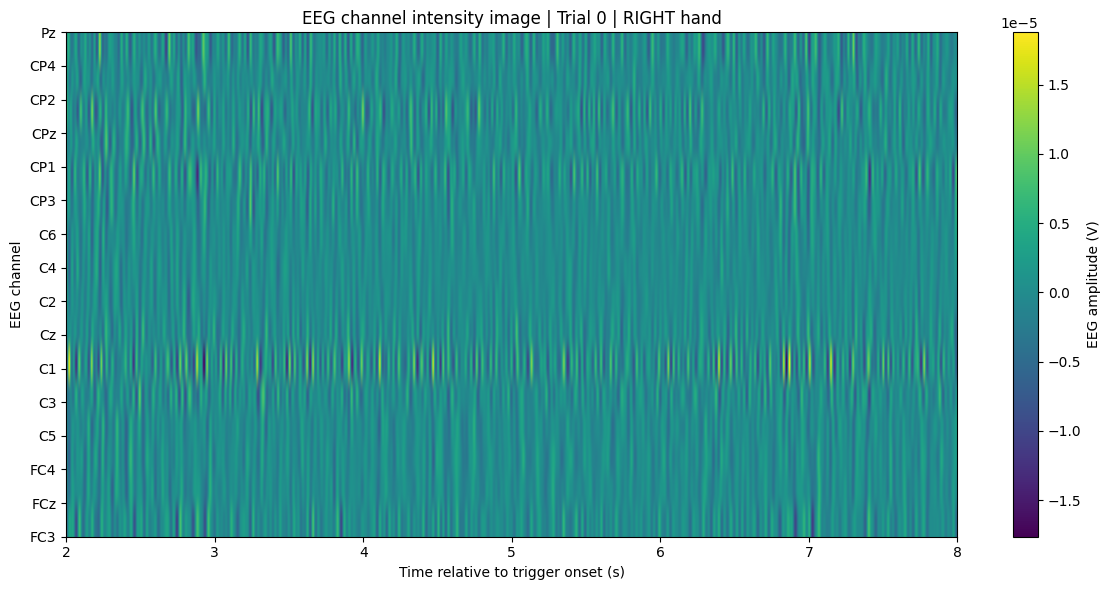

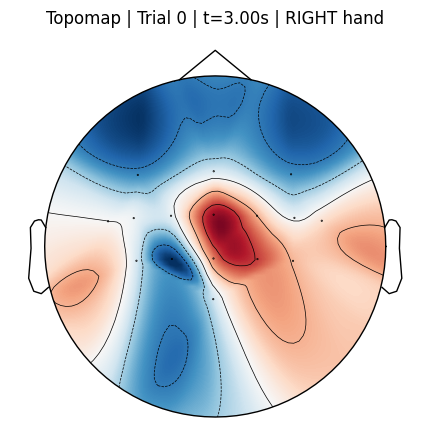

In [9]:
# =========================
# 8. VISUALIZE ONE FILE
# =========================

example_file = os.path.join(DATA_DIR, "P1_pre_training.mat")

ep_example, y_example = make_epochs_from_mat(
    example_file,
    tmin=2.0,
    tmax=8.0,
    l_freq=8.0,
    h_freq=30.0,
    baseline=True
)

plot_trial_16_channels(ep_example, y_example, trial_idx=0)
plot_trial_channel_image(ep_example, y_example, trial_idx=0)
plot_topomap_at_time(ep_example, y_example, trial_idx=0, time_sec=3.0)




EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Computing rank from data with rank=None
    Using tolerance 2.4 (2.2e-16 eps * 16 dim * 6.8e+14  max singular value)
    Estimated rank (data): 15
    data: rank 15 computed from 16 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 16 -> 15
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 2.4 (2.2e-16 eps * 16 dim * 6.7e+14  max singular value)
    Estimated rank (data): 15
    data: rank 15 computed from 16 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 16 -> 15
Estim

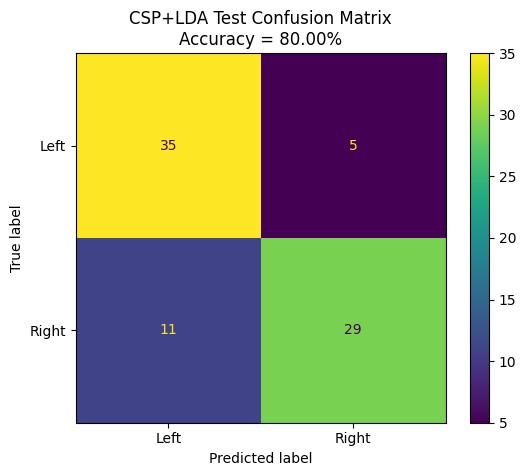

In [10]:
# =========================
# 9. RUN ONE EXAMPLE: P1 PRE
# =========================

p1_pre_train = os.path.join(DATA_DIR, "P1_pre_training.mat")
p1_pre_test = os.path.join(DATA_DIR, "P1_pre_test.mat")

p1_pre_result = run_csp_lda_with_all_accuracies(
    train_file=p1_pre_train,
    test_file=p1_pre_test,
    tmin=2.0,
    tmax=8.0,
    l_freq=8.0,
    h_freq=30.0,
    use_zscore=True,
    regularized=True,
    plot_confusion=True
)




In [11]:
# =========================
# 10. TIME WINDOW SEARCH EXAMPLE
# =========================

best_window_p1_pre, window_results_p1_pre = search_best_time_window(
    train_file=p1_pre_train,
    test_file=p1_pre_test,
    use_zscore=True,
    regularized=True
)




EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Computing rank from data with rank=None
    Using tolerance 1.4 (2.2e-16 eps * 16 dim * 3.9e+14  max singular value)
    Estimated rank (data): 15
    data: rank 15 computed from 16 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 16 -> 15
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 1.3 (2.2e-16 eps * 16 dim * 3.8e+14  max singular value)
    Estimated rank (data): 15
    data: rank 15 computed from 16 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 16 -> 15
Estim

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Computing rank from data with rank=None
    Using tolerance 2.6 (2.2e-16 eps * 16 dim * 7.3e+14  max singular value)
    Estimated rank (data): 15
    data: rank 15 computed from 16 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 16 -> 15
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (without PCA)
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Computing rank from data with rank=None
    Using tolerance 2.6 (2.2e-16 eps * 16 dim *

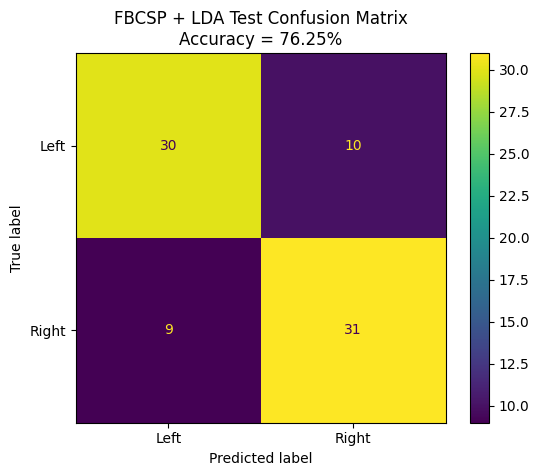

In [12]:
# =========================
# 11. FBCSP EXAMPLE
# =========================

p1_pre_fbcsp = run_fbcsp_lda(
    train_file=p1_pre_train,
    test_file=p1_pre_test,
    tmin=best_window_p1_pre["tmin"],
    tmax=best_window_p1_pre["tmax"],
    use_zscore=True,
    plot_confusion=True
)




In [13]:
# =========================
# 12. RUN ALL PATIENTS: BASIC IMPROVED CSP
# =========================

all_csp_results = {}

for patient in PATIENTS:
    all_csp_results[patient] = {}

    for session in SESSIONS:
        train_file = os.path.join(DATA_DIR, f"{patient}_{session}_training.mat")
        test_file = os.path.join(DATA_DIR, f"{patient}_{session}_test.mat")

        result = run_csp_lda_with_all_accuracies(
            train_file=train_file,
            test_file=test_file,
            tmin=2.0,
            tmax=8.0,
            l_freq=8.0,
            h_freq=30.0,
            use_zscore=True,
            regularized=True,
            plot_confusion=False
        )

        all_csp_results[patient][session] = result


print("\n========== IMPROVED CSP+LDA SUMMARY ==========")
print("Patient | Session | Train Acc | CV Acc           | Test Acc")
print("-------------------------------------------------------------")

for patient in PATIENTS:
    for session in SESSIONS:
        r = all_csp_results[patient][session]
        print(
            f"{patient:7s} | "
            f"{session.upper():7s} | "
            f"{r['train_accuracy']:8.2f}% | "
            f"{r['cv_accuracy_mean']:6.2f}% ± {r['cv_accuracy_std']:.2f}% | "
            f"{r['test_accuracy']:8.2f}%"
        )




EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Computing rank from data with rank=None
    Using tolerance 2.4 (2.2e-16 eps * 16 dim * 6.8e+14  max singular value)
    Estimated rank (data): 15
    data: rank 15 computed from 16 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 16 -> 15
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 2.4 (2.2e-16 eps * 16 dim * 6.7e+14  max singular value)
    Estimated rank (data): 15
    data: rank 15 computed from 16 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 16 -> 15
Estim

In [14]:
# =========================
# 13. RUN ALL PATIENTS: FBCSP
# =========================

all_fbcsp_results = {}

for patient in PATIENTS:
    all_fbcsp_results[patient] = {}

    for session in SESSIONS:
        train_file = os.path.join(DATA_DIR, f"{patient}_{session}_training.mat")
        test_file = os.path.join(DATA_DIR, f"{patient}_{session}_test.mat")

        result = run_fbcsp_lda(
            train_file=train_file,
            test_file=test_file,
            tmin=2.0,
            tmax=8.0,
            use_zscore=True,
            plot_confusion=False
        )

        all_fbcsp_results[patient][session] = result


print("\n========== FBCSP+LDA SUMMARY ==========")
print("Patient | Session | Train Acc | CV Acc           | Test Acc")
print("-------------------------------------------------------------")

for patient in PATIENTS:
    for session in SESSIONS:
        r = all_fbcsp_results[patient][session]
        print(
            f"{patient:7s} | "
            f"{session.upper():7s} | "
            f"{r['train_accuracy']:8.2f}% | "
            f"{r['cv_accuracy_mean']:6.2f}% ± {r['cv_accuracy_std']:.2f}% | "
            f"{r['test_accuracy']:8.2f}%"
        )




EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Computing rank from data with rank=None
    Using tolerance 2.8 (2.2e-16 eps * 16 dim * 8e+14  max singular value)
    Estimated rank (data): 15
    data: rank 15 computed from 16 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 16 -> 15
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
    Setting small data eigenvalues to zero (without PCA)
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Computing rank from data with rank=None
    Using tolerance 2.9 (2.2e-16 eps * 16 dim * 8

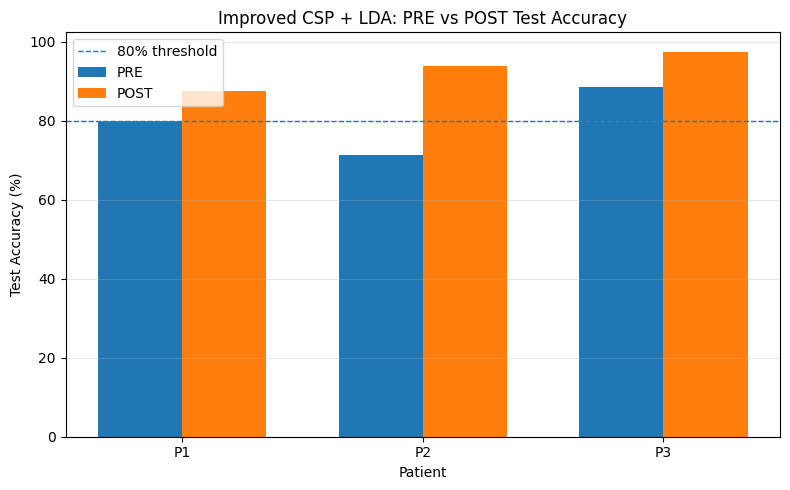

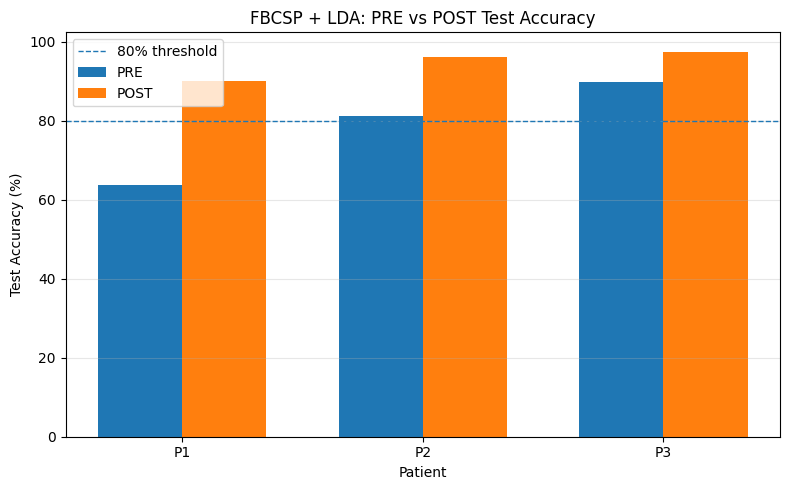

In [15]:
# =========================
# 14. PLOT PRE VS POST TEST ACCURACY
# =========================

def plot_pre_post_accuracy(results, title):
    patients = list(results.keys())

    pre_acc = [results[p]["pre"]["test_accuracy"] for p in patients]
    post_acc = [results[p]["post"]["test_accuracy"] for p in patients]

    x = np.arange(len(patients))
    width = 0.35

    plt.figure(figsize=(8, 5))

    plt.bar(x - width/2, pre_acc, width, label="PRE")
    plt.bar(x + width/2, post_acc, width, label="POST")

    plt.axhline(80, linestyle="--", linewidth=1, label="80% threshold")

    plt.xticks(x, patients)
    plt.ylabel("Test Accuracy (%)")
    plt.xlabel("Patient")
    plt.title(title)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_pre_post_accuracy(
    all_csp_results,
    "Improved CSP + LDA: PRE vs POST Test Accuracy"
)

plot_pre_post_accuracy(
    all_fbcsp_results,
    "FBCSP + LDA: PRE vs POST Test Accuracy"
)

In [16]:
# =========================
# PLOT ALL ACCURACIES (Train, CV, Test)
# =========================

def plot_all_accuracies(results, title="All Accuracies Comparison"):
    import numpy as np
    import matplotlib.pyplot as plt

    labels = []
    train_acc = []
    cv_acc = []
    test_acc = []

    # Extract values
    for patient in results:
        for session in ["pre", "post"]:
            r = results[patient][session]

            labels.append(f"{patient}_{session}")
            train_acc.append(r["train_accuracy"])
            cv_acc.append(r["cv_accuracy_mean"])
            test_acc.append(r["test_accuracy"])

    x = np.arange(len(labels))
    width = 0.25

    plt.figure(figsize=(12, 6))

    # Bars
    bars1 = plt.bar(x - width, train_acc, width, label="Train")
    bars2 = plt.bar(x, cv_acc, width, label="Cross-Validation")
    bars3 = plt.bar(x + width, test_acc, width, label="Test")

    # Add values on top
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height + 1,
                f"{height:.1f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    add_labels(bars1)
    add_labels(bars2)
    add_labels(bars3)

    # Styling
    plt.xticks(x, labels)
    plt.ylabel("Accuracy (%)")
    plt.xlabel("Patient & Session")
    plt.title(title)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.ylim(0, 105)
    plt.tight_layout()
    plt.show()

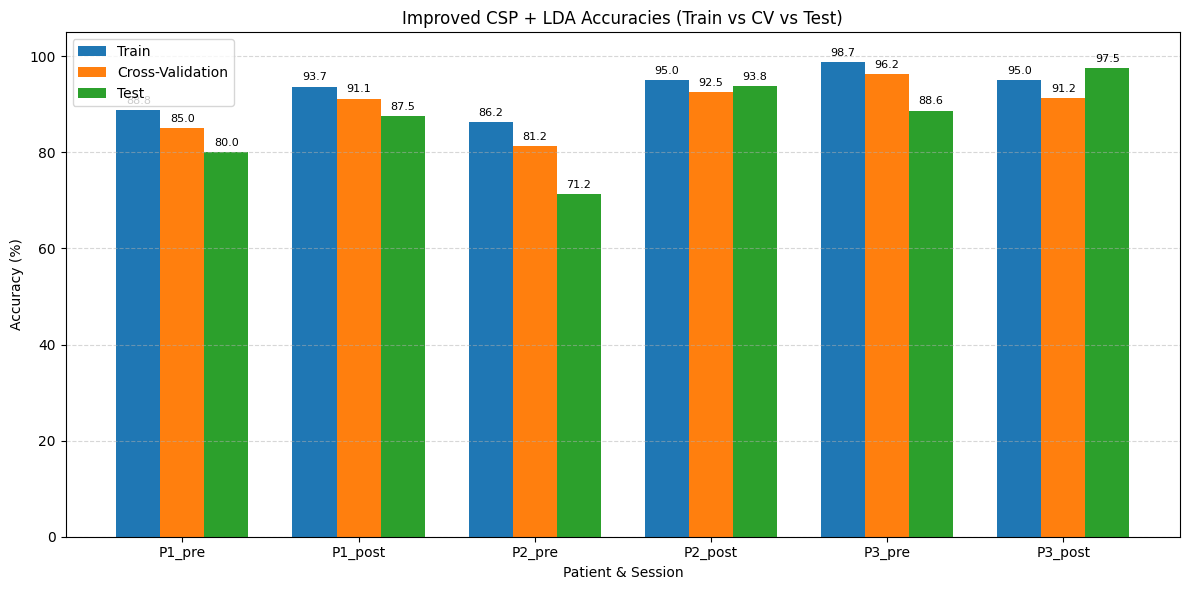

In [17]:
plot_all_accuracies(
    all_csp_results,
    title="Improved CSP + LDA Accuracies (Train vs CV vs Test)"
)

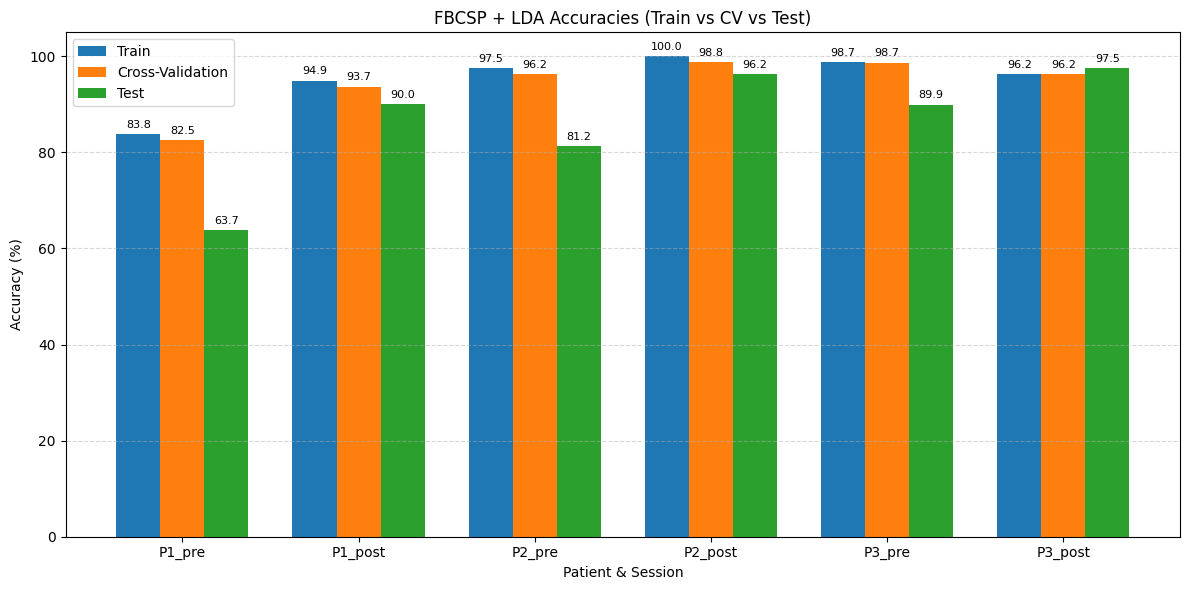

In [18]:
plot_all_accuracies(
    all_fbcsp_results,
    title="FBCSP + LDA Accuracies (Train vs CV vs Test)"
)